<a href="https://colab.research.google.com/github/Rohit-o/ML/blob/main/ML_Project1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Practice Project: Titanic Survival Prediction


In [1]:
!pip install numpy
!pip install matplotlib
!pip install pandas
!pip install scikit-learn
!pip install seaborn

### Import the required libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, ConfusionMatrixDisplay

### Load the Titanic dataset using Seaborn

In [3]:
titanic = sns.load_dataset('titanic')
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [4]:
titanic.count()

,0
survived,891
pclass,891
sex,891
age,714
sibsp,891
parch,891
fare,891
embarked,889
class,891
who,891


### Target
"survived" is our target class variable.

In [5]:
features = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'class', 'who', 'adult_male', 'alone']
target = 'survived'

X = titanic[features]
y = titanic[target]

### How Balanced are the classes

In [6]:
y.value_counts()

,count
survived,
0,549
1,342


### Split the data into training and testing sets

In [7]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, stratify= y, random_state= 42)

We use stratify in above code that is for layering purpose and random state is just for debugging or keeping the answer same each time. random_state can be any number from 0 to 100

### Define preprocessing transformers for numerical and categorical features
Automatically detect numerical and categorical columns and assign them to separate numeric and categorical features

In [8]:
numerical_features = X_train.select_dtypes(include = ['number']).columns.tolist()
categorical_features = X_train.select_dtypes(include = ['object', 'category']).columns.tolist()

print('numerical Features:', numerical_features)
print('categorical Features:', categorical_features)

numerical Features: ['pclass', 'age', 'sibsp', 'parch', 'fare']
categorical Features: ['sex', 'class', 'who']


### Define separate preprocessing pipelines for both feature types

Below "Pipeline" objects are just definitions of the preprocessing steps. They haven't actually processed any data yet.


In [9]:
numerical_transformer = Pipeline( steps = [
    ('imputer', SimpleImputer(strategy = 'median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline (steps = [
    ('impuetr', SimpleImputer(strategy= 'most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown = 'ignore'))

])

print('numerical transformer:', numerical_transformer)
print('categorical transformer:', categorical_transformer)

numerical transformer: Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                ('scaler', StandardScaler())])
categorical transformer: Pipeline(steps=[('impuetr', SimpleImputer(strategy='most_frequent')),
                ('onehot', OneHotEncoder(handle_unknown='ignore'))])


### Combine the transformers into a single column transformer
We'll use the sklearn "column transformer" estimator to separately transform the features, which will then concatenate the output as a single feature space, ready for input to a machine learning estimator.

In [10]:
preprocessor = ColumnTransformer(
    transformers = [
        ('num', numerical_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)

### Create a model pipeline
Now let's complete the model pipeline by combining the preprocessing with a Random Forest classifier

pipeline = Pipeline( steps = [ ('preprocessor', preprocessor), ('classifier', RandomForestClassifier(random_state = 42)) ]) This Pipeline is coming fromm which module, is it function or class. What does this preprocessor and Randomforestclassifier do ?

Let's break down this Pipeline object and its components:

Pipeline: This Pipeline class comes from the sklearn.pipeline module. It is a class, not a function. Its purpose is to chain together multiple processing steps into a single scikit-learn estimator. This simplifies the workflow, ensures consistent application of transformations and models, and helps prevent data leakage.

preprocessor: In your pipeline, preprocessor is an instance of ColumnTransformer, which you defined earlier. Its primary role is to apply different transformers to different columns of your dataset. Specifically:

It takes your original features (X_train) and routes the numerical_features through the numerical_transformer (which imputes missing values with the median and then scales them using StandardScaler).
It routes the categorical_features through the categorical_transformer (which imputes missing values with the most frequent value and then applies one-hot encoding).
Finally, it combines the processed numerical and categorical features into a single, transformed feature set that can be fed into the classifier.
RandomForestClassifier(random_state = 42): This is the actual machine learning model (also a class from sklearn.ensemble) that will be trained and used for predictions. A Random Forest is an ensemble learning method that operates by constructing a multitude of decision trees during training and outputting the class that is the mode of the classes (classification) or mean prediction (regression) of the individual trees.

random_state = 42 ensures that the randomness involved in building the decision trees (e.g., feature selection for splits) is reproducible. If you run the code multiple times with the same random_state, you will get the exact same forest and results.
In essence, this Pipeline first takes your raw data, preprocesses it consistently using the preprocessor (imputing and scaling numerical features, imputing and one-hot encoding categorical features), and then feeds that clean, transformed data directly into the RandomForestClassifier for training and prediction.

In [11]:
pipeline = Pipeline( steps = [
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(random_state = 42))
])

### Define a parameter grid¶
We'll use the grid in a cross validation search to optimize the model

What are we doing in param_grid and why do we make them?

param_grid is a dictionary that defines the range of hyperparameters that you want to search through to find the best combination for your machine learning model. In essence, it's a blueprint for hyperparameter optimization (often done using techniques like GridSearchCV or RandomizedSearchCV). <br>

Why? Machine learning models often have settings or configurations (hyperparameters) that are not learned from the data but are set before training. The performance of a model can vary significantly based on these settings. Instead of manually trying out different combinations, param_grid allows you to define a set of candidates, and an optimization algorithm will systematically test them to find the combination that yields the best model performance (e.g., highest accuracy on a validation set).
Let's break down the parameters you've defined for your RandomForestClassifier: <br>

classifier__n_estimators: Yes, this is directly related to the number of trees in the ensemble! For a RandomForestClassifier:

n_estimators specifies the number of individual decision trees that will be built in the forest. A larger number generally leads to more robust and stable models, but also increases computation time and can lead to diminishing returns after a certain point.
Here, you're telling the search to try building random forests with either 50 or 100 trees. <br>
classifier__max_depth: Yes, this parameter controls the maximum depth of each individual decision tree in the random forest: <br>

max_depth limits how many levels down each tree can grow. A deeper tree can capture more complex patterns but is also more prone to overfitting the training data. <br>
**None: Means nodes are expanded until all leaves are pure or until all leaves contain** less than min_samples_split samples.
10, 20: Specific maximum depths to explore. <br>
classifier__min_samples_split: This parameter, which should be spelled min_samples_split (I noticed a typo in your current code, I will fix that for you!), defines the minimum number of samples required to split an internal node: <br>

If a node has fewer samples than min_samples_split, it will not be split further, and it becomes a leaf node. This helps control the growth of individual trees and reduce overfitting. <br>
Is it related to information gain? While min_samples_split works in conjunction with the criteria used for splitting (like information gain, Gini impurity, or entropy), it's not directly calculating information gain. Instead, it acts as a pre-pruning rule: it tells the tree-building algorithm, "even if a split might improve information gain, don't split this node if it has too few samples." So, it's a stopping condition for splitting nodes, independent of the splitting criterion itself.
Here, you're asking the search to try requiring either 2 or 5 samples to split a node.


In [12]:
param_grid = {
    'classifier__n_estimators': [50, 100],
    'classifier__max_depth': [None, 10, 20],
    'classifier__min_samples_split': [2, 5]
    }

### Perform grid search cross-validation and fit the best model to the training data

First, a quick refresher on K-Fold Cross-Validation: It's a technique to evaluate machine learning models on a limited data sample. The dataset is divided into k parts (folds). The model is trained on k-1 folds and tested on the remaining 1 fold. This process is repeated k times, with each fold used exactly once as the test set. The results are then averaged to give a more robust estimate of model performance.

Now, for your specific questions:

**StratifiedKFold** <br>
What it does: StratifiedKFold is a variation of K-Fold cross-validation that ensures that each fold has approximately the same percentage of samples of each target class as the complete set. This is particularly important when dealing ***with imbalanced datasets (where one class has significantly fewer samples than others)***. <br>
Why we use it: If you have an imbalanced dataset, a standard KFold split might accidentally create folds where some classes are entirely missing or severely underrepresented in either the training or test set. This can lead to a biased evaluation of your model's performance, especially for the minority class. StratifiedKFold helps prevent this by maintaining the class distribution in each fold, leading to a more reliable performance estimate. <br>
Example: In your Titanic dataset, if survived=1 (survived) is a minority class, StratifiedKFold ensures that each of the 5 folds in your cv = StratifiedKFold(n_splits = 5, shuffle = True) will have roughly the same proportion of 'survived' and 'not survived' passengers as the overall dataset.

**GroupKFold**<br>
What it does: GroupKFold is used when your data has 'groups' of observations that are related and should not be split across training and testing sets. It ensures that the same group (e.g., patient ID, subject ID, family ID, experiment batch) does not appear in both the training and test sets within the same fold. <br>

Why we use it: If observations within a group are highly correlated (e.g., multiple medical readings from the same patient, multiple reviews from the same user, or in the case of the Titanic dataset, perhaps family members traveling together), splitting them between training and test sets can lead to data leakage. The model might learn characteristics specific to a group in the training set and then perform unrealistically well on other samples from the same group in the test set, overestimating its generalization ability.
Example: If your dataset included a 'family ID' column, and you used GroupKFold based on this ID, all members of a single family would either be entirely in the training set for a fold or entirely in the test set for that fold. This prevents the model from inadvertently learning about a family from the training set and then being tested on another member of the same family.
In your code (cv = StratifiedKFold(...)) <br>
You are using StratifiedKFold, which is a good choice for ensuring balanced class distribution in each fold, especially relevant for the 'survived' target variable which is typically imbalanced. There's also StratifiedGroupKFold which combines both behaviors, ensuring both class and group integrity across folds.

### Is it something related to sampling with replacement ?
That's a good question! No, cross-validation techniques like StratifiedKFold and GroupKFold **do not** involve sampling with replacement.

They operate on the principle of sampling without replacement. This means:

Each data point appears in the test set exactly once across all folds of the cross-validation process. This ensures that every observation gets a chance to be part of the hold-out validation set.
The partitions are mutually exclusive; once a data point is in a test fold, it is not put back into the pool to be selected for another test fold.
Sampling with replacement is typically associated with techniques like bootstrapping or bagging (as in Random Forests, where individual trees are trained on bootstrap samples). In those methods, data points can be selected multiple times for a single sample, and some data points might not be selected at all.

In [13]:
cv = StratifiedKFold(n_splits = 5, shuffle = True)


### Train the pipeline model

In [14]:
model = GridSearchCV(estimator=pipeline, param_grid=param_grid, cv=cv, scoring='accuracy', verbose=2)
model.fit(X_train, y_train)

Fitting 5 folds for each of 12 candidates, totalling 60 fits
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=50; total time=   0.2s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=50; total time=   0.3s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=50; total time=   0.4s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=50; total time=   0.2s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=50; total time=   0.3s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=100; total time=   0.4s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=100; total time=   0.2s
[CV] END classifier__max_depth=None, classifier__min_samples_split=2, classifier__n_estimators=100; total time=

GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=None, shuffle=True),
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['pclass',
                                                                          'age',
                                                                          'sibsp',
                                                                          'parch',
                                                                          'fare']),
                                                                        ('cat',
                                                                         Pipeline(steps=[('impuetr',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('onehot',
                                                                                          OneHotEncoder(handle_unknown='ignore'))]),
                                                                         ['sex',
                                                                          'class',
                                                                          'who'])])),
                                       ('classifier',
                                        RandomForestClassifier(random_state=42))]),
             param_grid={'classifier__max_depth': [None, 10, 20],
                         'classifier__min_samples_split': [2, 5],
                         'classifier__n_estimators': [50, 100]},
             scoring='accuracy', verbose=2)

### Get the model predictions from the grid search estimator on the unseen data
Also print a classification report

In [15]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.89      0.87       110
           1       0.81      0.74      0.77        69

    accuracy                           0.83       179
   macro avg       0.83      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179



### Plot the confusion matrix¶

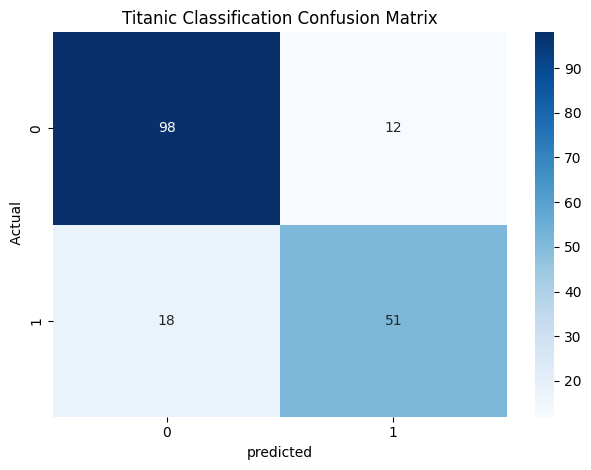

In [16]:
# Lets generate the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(conf_matrix, annot = True, cmap = 'Blues', fmt = 'd')

# Set the title and labels

plt.title ('Titanic Classification Confusion Matrix')
plt.xlabel('predicted')
plt.ylabel( ' Actual')

#Show the plot

plt.tight_layout()
plt.show()

## Feature importances
Let's figure out how to get the feature importances of our overall model.  You'll need to know how to do this for your final project.  
First, to obtain the categorical feature importances, we have to work our way backward through the modelling pipeline to associate the feature importances with their one-hot encoded input features that were transformed from the original categorical features.

We don't need to trace back through the pipeline for the numerical features, because we didn't transfrom them into new ones in any way.  
Remember, we went from categorical features to one-hot encoded features, using the 'cat' column transformer.

It is conceptually identical to the Routing Model Manager in Google OR-Tools.

Here's how you trace back through the trained model to access the one-hot encoded feature names:

In [17]:
model.best_estimator_['preprocessor'].named_transformers_['cat'].named_steps['onehot'].get_feature_names_out(categorical_features)


array(['sex_female', 'sex_male', 'class_First', 'class_Second',
       'class_Third', 'who_child', 'who_man', 'who_woman'], dtype=object)

You are likely drilling down through layers like this:
GridSearch --> best_estimator_ (Pipeline) -->  <br>
 named_steps['preprocessor'] (ColumnTransformer) --> <br>
 named_transformers_['cat'] (OneHotEncoder) --> <br>
 get_feature_names_out().


Notice how the one-hot encoded features are named - for example, sex was split into two boolean features indicating whether the sex is male or female.

Great! Now let's get all of the feature importances and associate them with their transformed feature names.

If your preprocessor (ColumnTransformer) was defined with numerical_features first, then categorical_features second, your manual list must follow that same order, or your labels won't match the importance scores!

In [18]:
if not hasattr(model, 'best_estimator_'):
    print("Model has not been fitted. Fitting the GridSearchCV model now...")
    # Ensure X_train and y_train are available from previous steps
    model.fit(X_train, y_train)

feature_importances = model.best_estimator_['classifier'].feature_importances_

# Combine the numerical and one-hot encoded categorical feature names
feature_names = numerical_features + list(model.best_estimator_['preprocessor']
                                          .named_transformers_['cat']
                                        .named_steps['onehot']
                                        .get_feature_names_out(categorical_features))

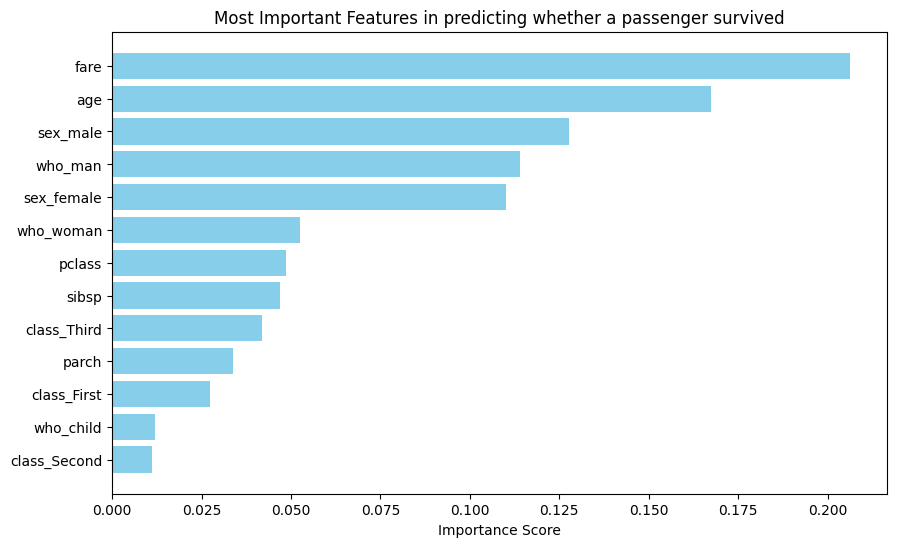


Test set accuracy: 82.68%


In [29]:

importance_df = pd.DataFrame({'Feature': feature_names,
                             'Importance': feature_importances}).sort_values(by ='Importance', ascending = False)
# Plotting
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='skyblue')
plt.gca().invert_yaxis()
plt.title('Most Important Features in predicting whether a passenger survived')
plt.xlabel('Importance Score')
plt.show()


# Print test score
test_score = model.score(X_test, y_test)
print(f"\nTest set accuracy: {test_score:.2%}")

**What can you say about these feature importances? Are they informative as is?**

The test set accuracy is somewhat satisfactory. However,regarding the feature impoirtances, it's crucially important to realize that there is most likely plenty of dependence amongst these variables, and a more detailed modelling approach including correlation analysis is required to draw proper conclusions. For example, no doubt there is significant information shared by the variables `age`, `sex_male`, and `who_man`.

### Try another model
In practice you would want to try out different models and even revisit the data analysis to improve your model performance. Maybe you can engineer new features or impute missing values to be able to use more data.

With Scikit-learn's powerful pipeline class, this is easy to do in a few steps. Let's update the pipeline and the parameter grid so we can train a Logistic Regression model and compare the performance of the two models.

In [21]:
# Replace RandomForestClassifier with LogisticRegression
pipeline.set_params(classifier=LogisticRegression(random_state=42))

# update the model's estimator to use the new pipeline
model.estimator = pipeline

# Define a new grid with Logistic Regression parameters
param_grid = {
    # 'classifier__n_estimators': [50, 100],
    # 'classifier__max_depth': [None, 10, 20],
    # 'classifier__min_samples_split': [2, 5],
    'classifier__solver' : ['liblinear'],
    'classifier__penalty': ['l1', 'l2'], #L1 is Lasso Regularization and L2 is Ridge Regularization
    'classifier__class_weight' : [None, 'balanced'] #imbalanced datasets
}

model.param_grid = param_grid

# Fit the updated pipeline with Logistic Regression
model.fit(X_train, y_train)

# Make predictions
y_pred = model.predict(X_test)


Fitting 5 folds for each of 4 candidates, totalling 20 fits
[CV] END classifier__class_weight=None, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.1s
[CV] END classifier__class_weight=None, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__class_weight=None, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__class_weight=None, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__class_weight=None, classifier__penalty=l1, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__class_weight=None, classifier__penalty=l2, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__class_weight=None, classifier__penalty=l2, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__class_weight=None, classifier__penalty=l2, classifier__solver=liblinear; total time=   0.0s
[CV] END classifier__class_weight=No

Display the clasification report for the new model and compare the results to your previous model.¶

In [22]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.84      0.89      0.86       110
           1       0.81      0.72      0.76        69

    accuracy                           0.83       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.83      0.83      0.82       179



Display the confusion matrix for the new model and compare the results to your previous model.

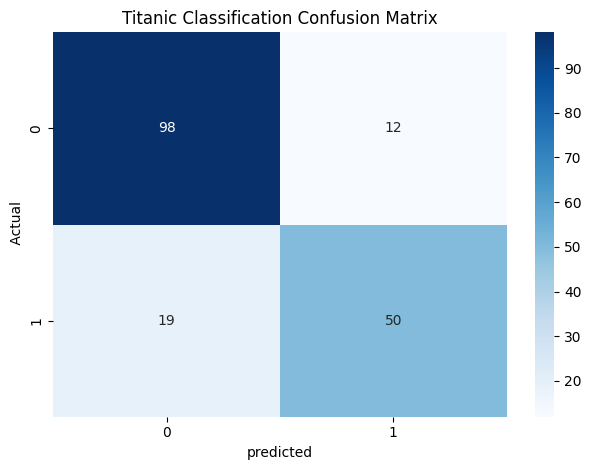

In [23]:
# Lets generate the confusion matrix
conf_matrix = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(conf_matrix, annot = True, cmap = 'Blues', fmt = 'd')

# Set the title and labels

plt.title ('Titanic Classification Confusion Matrix')
plt.xlabel('predicted')
plt.ylabel( ' Actual')

#Show the plot

plt.tight_layout()
plt.show()

Extract the logistic regression feature coefficients and plot their magnitude in a bar chart.

In [27]:
coefficients = model.best_estimator_.named_steps['classifier'].coef_[0]

# Combine numerical and categorical feature names
numerical_feature_names = numerical_features
categorical_feature_names = (model.best_estimator_.named_steps['preprocessor']
                                     .named_transformers_['cat']
                                     .named_steps['onehot']
                                     .get_feature_names_out(categorical_features)
                            )
feature_names = numerical_feature_names + list(categorical_feature_names)

### so best_estimator is for getting data from different values using what using model classfier and then store it into .feature_importances_?


model.best_estimator_ is how you retrieve the entire, optimal Pipeline that GridSearchCV identified as the best one after searching through all the hyperparameters.



1.   model is your GridSearchCV object.
2.   model.best_estimator_ is how you retrieve the entire, optimal Pipeline that GridSearchCV identified as the best one after searching through all the hyperparameters.
3. This Pipeline (model.best_estimator_) itself contains various steps, one of which is your 'classifier' (e.g., a RandomForestClassifier or LogisticRegression).
4. So, you then access the specific classifier step within that best pipeline using model.best_estimator_['classifier'].
5. Finally, it is this fitted classifier object (RandomForestClassifier or LogisticRegression) that possesses the feature_importances_ (or coef_) attribute. This attribute is populated after the classifier itself has been trained (fitted) as part of the best pipeline. <br>

So, it's not that best_estimator_ is for getting data and storing it into feature_importances_. Instead, 'best_estimator_' gives you access to the fully trained components of the optimal model, and one of those components (the classifier) already has its feature_importances_ attribute (containing the scores) available.




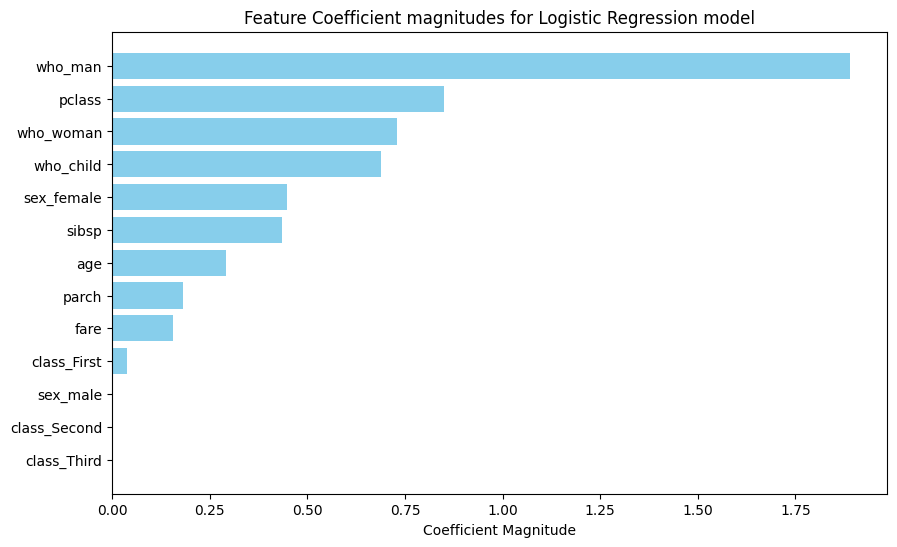


Test set accuracy: 82.68%


In [28]:
# Create a DataFrame for the coefficients
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
}).sort_values(by='Coefficient', ascending=False, key=abs)  # Sort by absolute values

# Plotting
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Coefficient'].abs(), color='skyblue')
plt.gca().invert_yaxis()
plt.title('Feature Coefficient magnitudes for Logistic Regression model')
plt.xlabel('Coefficient Magnitude')
plt.show()

# Print test score
test_score = model.best_estimator_.score(X_test, y_test)
print(f"\nTest set accuracy: {test_score:.2%}")

Although the performances of the two models are virtually identical, the features that are important to the two models are very different. This suggests there must be more work to do to better grasp the actual feature importancdes. A smentioned above, it's crucially important to realize that there is most likely plenty of dependence amongst these variables, and a more detailed modelling approach including correlation analysis is required to draw proper conclusions. For example, there is significant information implied between the variables who_man, who_woman, and who_child, because if a person is neither a man nor a woman, then they must be a child.